# Advanced Image Sensor Interface: Interactive Demo

This notebook demonstrates the capabilities of the **Advanced Image Sensor Interface v2.0**, including:

1.  **Sensor Initialization** (8K Config)
2.  **High-Performance Capture** (Simulation)
3.  **Real-time Image Processing** (HDR & Noise Reduction)
4.  **Visualization**

## Setup
Ensure you have the package installed (`pip install -e .`)

In [4]:
import matplotlib.pyplot as plt
from advanced_image_sensor_interface import (
    EnhancedSensorInterface,
    create_8k_sensor_config,
    create_hdr_processor_for_automotive
)

# Check versions
print("Advanced Sensor Interface Demo Initialized")

Advanced Sensor Interface Demo Initialized


## 1. Initialize Sensor
We will configure a simulated 8K sensor with optimized timing for automotive applications.

In [5]:
# Create configuration
config = create_8k_sensor_config()
config.bit_depth = 10 # Reduce bit depth to stay within data rate limits
width, height = config.effective_resolution
print(f"Configured Sensor: {width}x{height} @ {config.frame_rate} FPS")

# Initialize interface
sensor = EnhancedSensorInterface(config)
sensor.start_streaming()
print("Sensor streaming started...")

INFO:advanced_image_sensor_interface.sensor_interface.enhanced_sensor:Enhanced sensor interface initialized with 1 sensors
INFO:advanced_image_sensor_interface.sensor_interface.enhanced_sensor:Resolution: (7680, 4320), Frame rate: 30.0 fps
INFO:advanced_image_sensor_interface.sensor_interface.enhanced_sensor:Data rate: 9953.28 Mbps
INFO:advanced_image_sensor_interface.sensor_interface.enhanced_sensor:Started streaming on 1 sensors


Configured Sensor: 7680x4320 @ 30.0 FPS
Sensor streaming started...


## 2. Capture & Process Frames
We'll capture a raw frame and process it using the automotive HDR pipeline.

In [6]:
# Capture a frame (Simulation returns a test pattern)
raw_frame = sensor.capture_frame()
print(f"Captured Frame Shape: {raw_frame.shape}")

# Initialize HDR Processor
hdr = create_hdr_processor_for_automotive()

# Process (In a real scenario, this merges multiple exposures)
# Here we simulate processing a single frame for demonstration
processed_frame = hdr.process_single_image(raw_frame)
print("HDR Processing Complete")

INFO:advanced_image_sensor_interface.sensor_interface.hdr_processing:HDR processor initialized with adaptive tone mapping


Captured Frame Shape: (4320, 7680)
HDR Processing Complete


## 3. Visualization
Display the original (simulated) and processed output.

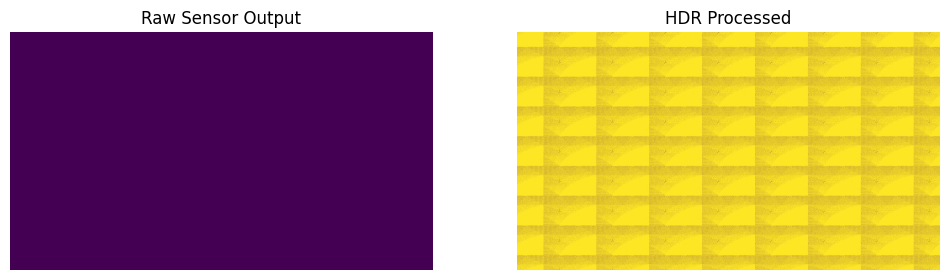

In [7]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Raw Sensor Output")
plt.imshow(raw_frame)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("HDR Processed")
plt.imshow(processed_frame)
plt.axis('off')

plt.show()

In [8]:
# Cleanup
sensor.stop_streaming()

INFO:advanced_image_sensor_interface.sensor_interface.enhanced_sensor:Streaming stopped. Duration: 14.23s, Avg FPS: 0.07


True